# Zadanie obowiązkowe [0-10] pkt

1. [0-1 pkt] Zaproponuj EDA po skalowaniu cech (tj. analiza macierzy zliczeń)
1. [0-2 pkt] Dostosuj parametry wektoryzacji (np. `ngram_range`, `min_df`, `max_df`) na podstawie analizy wyżej. Zrób wyszukiwanie po parametrach, używając `ROCAUC` jako miary (zob. [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html))
1. [0-1 pkt] Porównanj wyniki z rozkładem Bernoulliego. Zidentyfikuj przykłady, dla których każdy z modeli działa lepiej
1. [0-1.5 pkt] Użyj transformacji [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html) zaraz po wektoryzacji dla rozkładu wielomianowego i Gaussowskiego. W tym celu użyj funkcjonalności `Pipeline`
   1. w przypadku rozkładu Gaussowskiego wymagane będzie użycia transformatora postaci gęstej macierzy (patrz kod niżej)
   1. Skomentuj, dlaczego model z rozkładem Gaussa działa gorzej
1. [0-1.5 pkt] Wytrenuj [regresję logistyczną](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), robiąc przeszukanie po hiperparametrach  
1. [0-1 pkt] Porównaj krzywe kalibracyjne (użyj tego [API](https://scikit-learn.org/stable/modules/calibration.html)) dla obu modeli. Skomentuj wyniki
1. [0-2 pkt] Spróbuj znaleźć dwa reprezentatywne n-gramy, które najlepiej separują klasy. Wyrysuj obszary decyzyjne dla obu klasyfikatorów

## EDA po skalowaniu cech

### Skalowanie z laba

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import sklearn

sklearn.set_config(transform_output="pandas")

In [2]:
sms = pd.read_csv('../Lab04/sms+spam+collection/SMSSpamCollection', 
                  delimiter='\t', header=None, names=['is_spam', 'text'])

sms['is_spam'] = sms['is_spam'].map({'spam': 1, 'ham': 0}).astype('int8')

X = sms['text']
y = sms['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=0)

vect = CountVectorizer(stop_words='english')
vect.fit(X_train)
X_train_scaled     = vect.transform(X_train)
X_test_scaled      = vect.transform(X_test)
X_train_scaled_inv = vect.inverse_transform(X_train_scaled)
X_test_scaled_inv  = vect.inverse_transform(X_test_scaled)

### Podstawowe statystyki

In [3]:
print("Wymiary macierzy (train):", X_train_scaled.shape)
print("Wymiary macierzy (test):", X_test_scaled.shape)

sparsity_train = 1 - X_train_scaled.nnz / (X_train_scaled.shape[0] * X_train_scaled.shape[1])
sparsity_test = 1 - X_test_scaled.nnz / (X_test_scaled.shape[0] * X_test_scaled.shape[1])
print(f"\nGęstość macierzy treningowej: {sparsity_train:.2%}")
print(f"Gęstość macierzy testowej: {sparsity_test:.2%}")

counts_train = X_train_scaled.toarray().astype('int32')
print(f"\nŚrednia liczba słów na wiersz: {counts_train.sum(axis=1).mean():.2f}")
print(f"Min/Max słów na wiersz: {counts_train.sum(axis=1).min()}/{counts_train.sum(axis=1).max()}")
print(f"Średnia liczba unikalnych słów na wiersz: {(counts_train > 0).sum(axis=1).mean():.2f}")

Wymiary macierzy (train): (4457, 7442)
Wymiary macierzy (test): (1115, 7442)

Gęstość macierzy treningowej: 99.89%
Gęstość macierzy testowej: 99.91%

Średnia liczba słów na wiersz: 8.22
Min/Max słów na wiersz: 0/72
Średnia liczba unikalnych słów na wiersz: 7.83


### Statystyki słów i długości

In [4]:
feature_names = vect.get_feature_names_out()
word_freq = np.asarray(X_train_scaled.sum(axis=0)).flatten()
word_freq_df = pd.DataFrame({
    'word': feature_names,
    'frequency': word_freq
}).sort_values('frequency', ascending=False)

print("Top 20 najczęstszych słów:")
print(word_freq_df.head(20).to_string(index=False))

Top 20 najczęstszych słów:
 word  frequency
   ur        317
 just        303
   gt        255
   lt        253
   ok        250
 free        224
 know        219
   ll        212
 come        197
 like        191
 good        189
  got        186
  day        176
 time        175
 love        172
 send        166
 text        149
 want        148
  txt        145
going        142


In [5]:
X_train_df = pd.DataFrame(X_train_scaled.toarray(), columns=feature_names)
X_train_df['is_spam'] = y_train.values

freq_spam = X_train_df[X_train_df['is_spam'] == 1].mean().drop('is_spam')
freq_ham = X_train_df[X_train_df['is_spam'] == 0].mean().drop('is_spam')

print("Top 10 słów charakterystycznych dla SPAMU:")
spam_words = (freq_spam - freq_ham).sort_values(ascending=False).head(10)
print(spam_words.to_string())

print("\n\nTop 10 słów charakterystycznych dla HAM:")
ham_words = (freq_ham - freq_spam).sort_values(ascending=False).head(10)
print(ham_words.to_string())

Top 10 słów charakterystycznych dla SPAMU:
free      0.289601
txt       0.219298
mobile    0.167459
stop      0.152243
claim     0.147157
ur        0.145757
text      0.142938
www       0.133520
reply     0.127277
prize     0.127090


Top 10 słów charakterystycznych dla HAM:
gt       0.066079
lt       0.065561
ok       0.057058
ll       0.047211
come     0.047187
got      0.036611
lor      0.035242
da       0.031614
good     0.031594
sorry    0.030979


Widać np że `SPAM` ma dużą ilość takich samych słów podczas gdy `HAM` jest bardziej zróżnicowany jeśli chodzi o słowa.

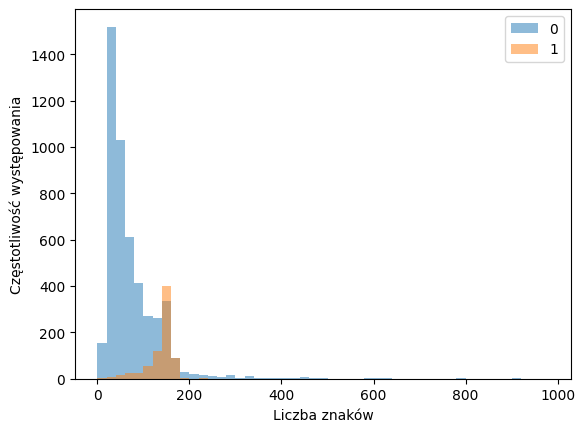

In [6]:
for cat in sms['is_spam'].unique():
    sms[sms['is_spam'] == cat]['text'].str.len().plot(bins=np.arange(0, 1000, 20), 
                                                      kind='hist', label=cat, alpha=0.5)
plt.xlabel('Liczba znaków')
plt.ylabel('Częstotliwość występowania')
plt.legend();

Widać, że `HAM` ma w większości krótkie wiadomości chociaż są też bardzo długie, podczas gdy `SPAM` trzyma się w średniej długości wiadomości.

## Wektoryzacja

In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [8]:
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'vectorizer__min_df': [1, 2, 5],
    'vectorizer__max_df': [1.0, 0.9, 0.8]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=make_scorer(roc_auc_score),
    n_jobs=-1,
    verbose=1
)

In [9]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'vectorizer__max_df': [1.0, 0.9, ...], 'vectorizer__min_df': [1, 2, ...], 'vectorizer__ngram_range': [(1, ...), (1, ...), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [10]:
print("WYNIKI:")
print(f"Najlepszy ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Dla:")
for param, value in grid_search.best_params_.items():
    param_name = param.replace('vectorizer__', '')
    print(f"\t{param_name}: {value}")

y_test_pred = grid_search.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC na test: {test_roc_auc:.4f}")

WYNIKI:
Najlepszy ROC-AUC: 0.9667
Dla:
	max_df: 1.0
	min_df: 1
	ngram_range: (1, 2)

ROC-AUC na test: 0.9701


Wynik wyszedł bardzo dobry. Ciekawe jest to, że najlepsze było użycie bigramów, ale nie trigramów. Pewnie jest to spowodowane przez to, że bigramy nadawały wystarczająco dużo kontekstu , a trigramy powodowały zbyt duże przeuczenie na zbiorze treningowym - były zbyt specificzne.

Optymalny wybór `min_df` i `max_df` jest spowodowany balansem między filtracją szumu (słowa zbyt rzadkie) a zachowaniem informacji. Zbyt wysoka wartość mogłaby stracić ważne cechy. ROC-AUC zarówno na zbiorze treningowym jak i testowym jest bardzo bliskie, co sugeruje, że model generalizuje dobrze i nie przeuczył się.

## Porównanie z rozkładem Bernoulliego

In [11]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix

In [12]:
best_vectorizer = grid_search.best_estimator_.named_steps['vectorizer']
mnb = grid_search.best_estimator_.named_steps['classifier']

X_train_best = best_vectorizer.transform(X_train)
X_test_best = best_vectorizer.transform(X_test)

y_mnb_prob = mnb.predict_proba(X_test_best)[:, 1]
mnb_roc = roc_auc_score(y_test, y_mnb_prob)

In [13]:
X_train_bin = (X_train_best > 0).astype(int)
X_test_bin = (X_test_best > 0).astype(int)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
y_bnb_prob = bnb.predict_proba(X_test_bin)[:, 1]
bnb_roc = roc_auc_score(y_test, y_bnb_prob)

In [14]:
print(f"\n{'Metryka':<30} {'Multinomial NB':<20} {'Bernoulli NB':<20}")
print("-" * 70)
print(f"{'ROC-AUC':<30} {mnb_roc:<20.4f} {bnb_roc:<20.4f}")

mnb_cm = confusion_matrix(y_test, y_mnb_prob > 0.5)
bnb_cm = confusion_matrix(y_test, y_bnb_prob > 0.5)

print(f"{'True Negatives (TN)':<30} {mnb_cm[0,0]:<20} {bnb_cm[0,0]:<20}")
print(f"{'False Positives (FP)':<30} {mnb_cm[0,1]:<20} {bnb_cm[0,1]:<20}")
print(f"{'False Negatives (FN)':<30} {mnb_cm[1,0]:<20} {bnb_cm[1,0]:<20}")
print(f"{'True Positives (TP)':<30} {mnb_cm[1,1]:<20} {bnb_cm[1,1]:<20}")

mnb_precision = mnb_cm[1,1] / (mnb_cm[1,1] + mnb_cm[0,1])
bnb_precision = bnb_cm[1,1] / (bnb_cm[1,1] + bnb_cm[0,1])
mnb_recall = mnb_cm[1,1] / (mnb_cm[1,1] + mnb_cm[1,0])
bnb_recall = bnb_cm[1,1] / (bnb_cm[1,1] + bnb_cm[1,0])

print(f"{'Precyzja (spam)':<30} {mnb_precision:<20.4f} {bnb_precision:<20.4f}")
print(f"{'Recall (spam)':<30} {mnb_recall:<20.4f} {bnb_recall:<20.4f}")


Metryka                        Multinomial NB       Bernoulli NB        
----------------------------------------------------------------------
ROC-AUC                        0.9701               0.9895              
True Negatives (TN)            959                  966                 
False Positives (FP)           7                    0                   
False Negatives (FN)           16                   76                  
True Positives (TP)            133                  73                  
Precyzja (spam)                0.9500               1.0000              
Recall (spam)                  0.8926               0.4899              


Bernoulli ma perfekcyjną precyzję, ale bardzo niską czułość - pomija ponad połowę rzeczywistych przypadków spamu.

Ogólnie BernoulliNB radzi sobie lepiej jeśli chodzi o ROC-AUC.

In [15]:
disagreement = (y_mnb_prob > 0.5) != (y_bnb_prob > 0.5)
disagreement_indices = np.where(disagreement)[0]

print("PRZYKŁADY, GDZIE MODELE SIĘ RÓŻNIĄ:")
print(f"Liczba różnic: {len(disagreement_indices)} na {len(y_test)}")

print("\nPrzykłady gdzie Multinomial mówi SPAM, a Bernoulli mówi HAM:")
mnb_spam_bnb_ham = disagreement_indices[(y_mnb_prob[disagreement_indices] > 0.5) & 
                                            (y_bnb_prob[disagreement_indices] <= 0.5)]

for i, idx in enumerate(mnb_spam_bnb_ham[:5]):
    true_label = "SPAM" if y_test.iloc[idx] == 1 else "HAM"
    print(f"\n  Przykład {i+1} (rzeczywisty: {true_label}):")
    print(f"    Tekst: {X_test.iloc[idx][:100]}...")


bnb_spam_mnb_ham = disagreement_indices[(y_bnb_prob[disagreement_indices] > 0.5) & 
                                            (y_mnb_prob[disagreement_indices] <= 0.5)]


print("\nIlość przykładów, gdzie Multinomial mówi HAM, a Bernoulli mówi SPAM:", len(bnb_spam_mnb_ham))


PRZYKŁADY, GDZIE MODELE SIĘ RÓŻNIĄ:
Liczba różnic: 67 na 1115

Przykłady gdzie Multinomial mówi SPAM, a Bernoulli mówi HAM:

  Przykład 1 (rzeczywisty: HAM):
    Tekst: We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us...

  Przykład 2 (rzeczywisty: SPAM):
    Tekst: U 447801259231 have a secret admirer who is looking 2 make contact with U-find out who they R*reveal...

  Przykład 3 (rzeczywisty: SPAM):
    Tekst: Valentines Day Special! Win over £1000 in our quiz and take your partner on the trip of a lifetime! ...

  Przykład 4 (rzeczywisty: SPAM):
    Tekst: FreeMsg>FAV XMAS TONES!Reply REAL...

  Przykład 5 (rzeczywisty: SPAM):
    Tekst: For your chance to WIN a FREE Bluetooth Headset then simply reply back with "ADP"...

Ilość przykładów, gdzie Multinomial mówi HAM, a Bernoulli mówi SPAM: 0


## Transformacja IDF

In [16]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import GaussianNB

In [17]:
from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()

In [18]:
pipeline_idf_mnb = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2), stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])

pipeline_idf_gnb = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2), stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('dense_tf', DenseTransformer()),
    ('classifier', GaussianNB())
])

In [19]:
pipeline_idf_mnb.fit(X_train, y_train)
pipeline_idf_gnb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [20]:
y_mnb_idf_prob = pipeline_idf_mnb.predict_proba(X_test)[:, 1]
mnb_idf_roc = roc_auc_score(y_test, y_mnb_idf_prob)

y_gnb_idf_prob = pipeline_idf_gnb.predict_proba(X_test)[:, 1]
gnb_idf_roc = roc_auc_score(y_test, y_gnb_idf_prob)

print(f"{'':<10} {'Multinomial':<15} {'Gaussian':<15}")
print("-" * 40)
print(f"{'ROC-AUC':<10} {mnb_idf_roc:<15.4f} {gnb_idf_roc:<15.4f}")

           Multinomial     Gaussian       
----------------------------------------
ROC-AUC    0.9743          0.8842         


GaussianNB radzi sobie znacznie gorzej (spadek ROC-AUC około 0.1). Jest to spowodowane przez niezgodność między założeniami modelu a danymi. GaussianNB zakłada gaussowski rozkład cech w każdej klasie, ale po transformacji TF-IDF dane mają rozkład mocno asymetryczny z koncentracją blisko zera. Dodatkowo, TF-IDF zawsze generuje wartości nieujemne (0 do około 1), co powoduje, że rozkład jest niedostosowany do symetrycznego rozkładu gaussiańskiego.

## Regresja Logistyczna

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
param_grid_reg = [
    {
        "reg__l1_ratio": [0.0], # l2
        "reg__C": [0.01, 0.1, 1, 10, 100],
        "reg__solver": ['lbfgs', 'saga', 'liblinear'] 
    },
    {
        "reg__l1_ratio": [1.0], # l1
        "reg__C": [0.01, 0.1, 1, 10, 100],
        "reg__solver": ['saga', 'liblinear']
    },
    {
        "reg__l1_ratio": [0.5], # elasticnet
        "reg__C": [0.01, 0.1, 1, 10, 100],
        "reg__solver": ['saga']
    }
]

pipeline_reg = Pipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,2), stop_words='english')),
    ('reg', LogisticRegression(max_iter=1000))
])

grid_search_reg = GridSearchCV(
    estimator=pipeline_reg,
    param_grid=param_grid_reg,
    cv=5,
    scoring=make_scorer(roc_auc_score),
    n_jobs=-1,
    verbose=1
)

In [23]:
grid_search_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\piotr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'reg__C': [0.01, 0.1, ...], 'reg__l1_ratio': [0.0], 'reg__solver': ['lbfgs', 'saga', ...]}, {'reg__C': [0.01, 0.1, ...], 'reg__l1_ratio': [1.0], 'reg__solver': ['saga', 'liblinear']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the ver

In [24]:
print("WYNIKI:")
print(f"Najlepszy ROC-AUC: {grid_search_reg.best_score_:.4f}")
print(f"Dla:")
for param, value in grid_search_reg.best_params_.items():
    param_name = param.replace('vectorizer__', '')
    print(f"\t{param_name}: {value}")

y_test_pred = grid_search_reg.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC na test: {test_roc_auc:.4f}")

WYNIKI:
Najlepszy ROC-AUC: 0.9390
Dla:
	reg__C: 10
	reg__l1_ratio: 1.0
	reg__solver: saga

ROC-AUC na test: 0.9698


Wybór regularyzacji L1 (`l1_ratio=1.0`) jako optymalnej wskazuje, że najlepsze okazało się zerowanie wag dla mniej istotnych słów.

Wysokie `C` oznacza słabszą regularyzacje.

Wybór `saga` ma duży sens, bo zazwyczaj radzi sobie najlepiej na dużych zbiorów danych.

## Krzywe kalibracyjne

In [25]:
from sklearn.calibration import CalibrationDisplay

In [26]:
best_model_reg = grid_search_reg.best_estimator_
best_model_idf = pipeline_idf_mnb

In [27]:
best_model_reg.predict_proba(X_test)[:, 1]

array([0.01436484, 0.00472815, 0.0202977 , ..., 0.00136499, 0.06033746,
       0.00655434], shape=(1115,))

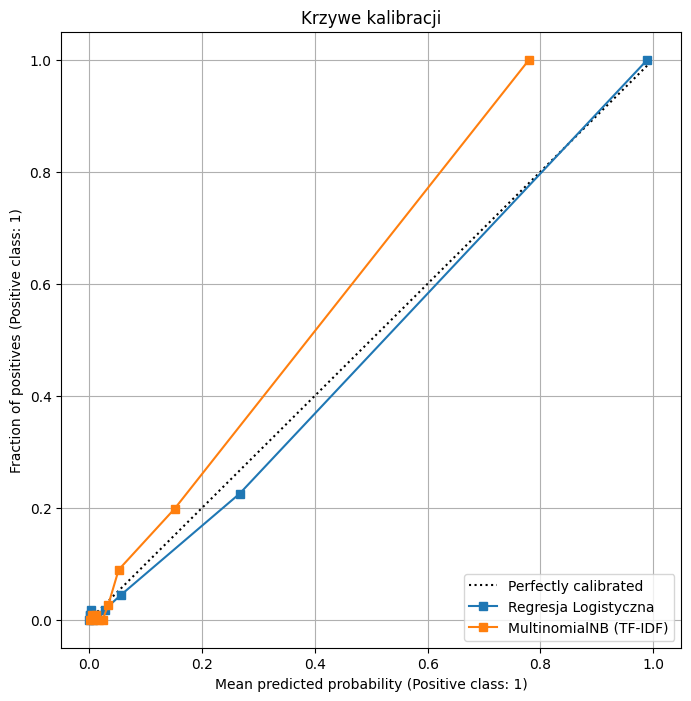

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
CalibrationDisplay.from_estimator(best_model_reg, X_test, y_test, n_bins=10, strategy='quantile', ax=ax, name='Regresja Logistyczna')
CalibrationDisplay.from_estimator(best_model_idf, X_test, y_test, n_bins=10, strategy='quantile', ax=ax, name='MultinomialNB (TF-IDF)')

plt.title("Krzywe kalibracji")
plt.grid()
plt.show()

Widać m.in. że większość danych testowych należy do klasy negatywnej (`HAM`), przez co trzeba było użyć `startegy='quantile'`, żeby zniwelować szum wynikający z tego niezbilansowania.

Wyniki pokazują, że:
 - Regresja Logistyczna (niebieskie) - jest bardzo dobrze skalibrowana (`y=x`). Oznacza to, że dla danych, którym model przypisuje prawdopodobieństwo X%, rzeczywisty udział klasy pozytywnej w tej grupie to również X%.
 - MNB (pomarańczowa) - jest słabo skalibrowana. Widać jak krzywa znajduje się nad osią referencyjną, co oznacza niedoszacowanie klasy pozytywnej.

## Obszary decyzyjne n-gramów

In [29]:
from sklearn.inspection import DecisionBoundaryDisplay

In [30]:
vectorizer = best_model_idf.named_steps['vectorizer']
feature_names = np.array(vectorizer.get_feature_names_out())
classifier = best_model_idf.named_steps['classifier']
coefs = classifier.feature_log_prob_[1] - classifier.feature_log_prob_[0]

# Najbardziej dzielące n-gramy to minmalny i maksymalny jeśli chodzi o ich wagę
idx_class_0 = coefs.argmin()
idx_class_1 = coefs.argmax()

ngram_class_0 = feature_names[idx_class_0]
ngram_class_1 = feature_names[idx_class_1]

print(f"Najlepszy n-gram dla klasy 'HAM': '{ngram_class_0}' (waga: {coefs[idx_class_0]:.4f})")
print(f"Najlepszy n-gram dla klasy 'SPAM': '{ngram_class_1}' (waga: {coefs[idx_class_1]:.4f})")

Najlepszy n-gram dla klasy 'HAM': 'ok' (waga: -3.5203)
Najlepszy n-gram dla klasy 'SPAM': 'claim' (waga: 2.7097)


In [31]:
# transforamcja danych do przestrzeni 2D (tylko te dwa n-gramy)
X_train_transformed = vectorizer.transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

X_train_2d = X_train_transformed[:, [idx_class_0, idx_class_1]].toarray()
X_test_2d = X_test_transformed[:, [idx_class_0, idx_class_1]].toarray()

In [32]:
# utworzenie modeli na danych 2D
clf_reg_2d = LogisticRegression(max_iter=1000).fit(X_train_2d, y_train)
clf_mnb_2d = MultinomialNB().fit(X_train_2d, y_train)

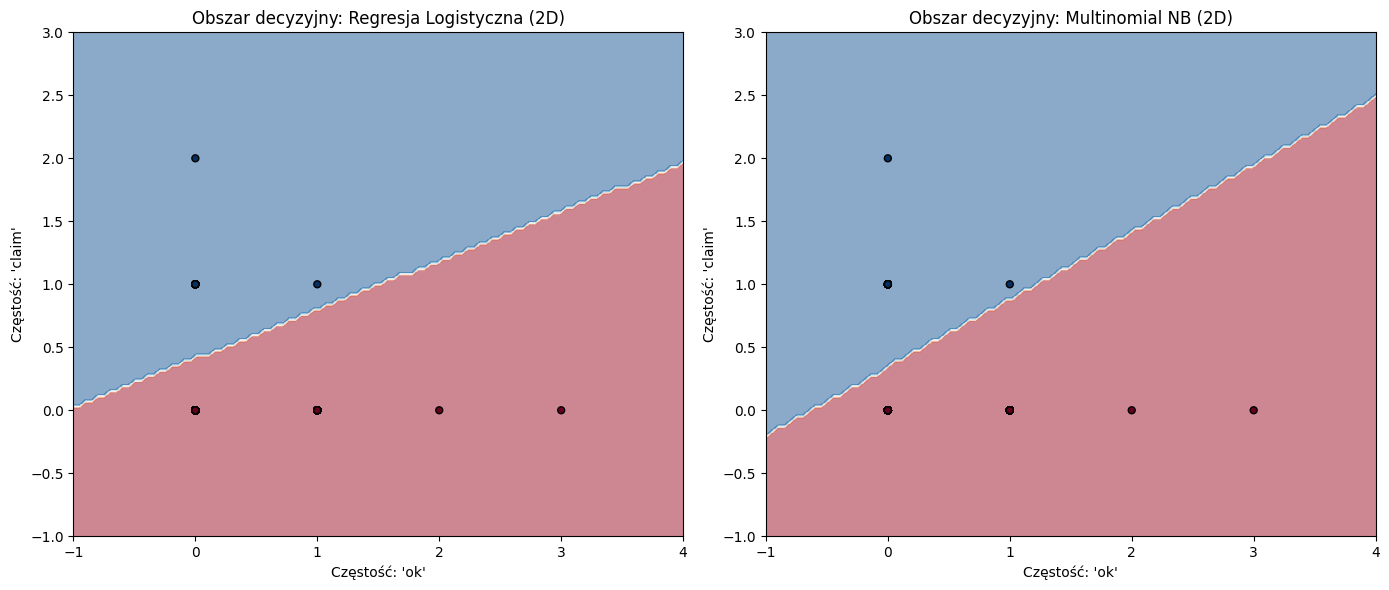

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

DecisionBoundaryDisplay.from_estimator(
    clf_reg_2d, X_test_2d, response_method="predict",
    cmap=plt.cm.RdBu, alpha=0.5, ax=ax[0]
)
scatter_reg = ax[0].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap=plt.cm.RdBu, edgecolors='k', s=25)
ax[0].set_title('Obszar decyzyjny: Regresja Logistyczna (2D)')
ax[0].set_xlabel(f"Częstość: '{ngram_class_0}'")
ax[0].set_ylabel(f"Częstość: '{ngram_class_1}'")

DecisionBoundaryDisplay.from_estimator(
    clf_mnb_2d, X_test_2d, response_method="predict",
    cmap=plt.cm.RdBu, alpha=0.5, ax=ax[1]
)
scatter_mnb = ax[1].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap=plt.cm.RdBu, edgecolors='k', s=25)
ax[1].set_title('Obszar decyzyjny: Multinomial NB (2D)')
ax[1].set_xlabel(f"Częstość: '{ngram_class_0}'")
ax[1].set_ylabel(f"Częstość: '{ngram_class_1}'")

plt.tight_layout()
plt.show()

Widać, że najbardziej świadczącym o spamie jest słowo `claim`, a najbardziej świadczące o prawdziwej wiadomości jest `ok`. Ma to logiczny sens, bo wiadomości spamerskie często wymagają kliknięcia linku, w kórym mamy coś odebrać, a `ok` jest mocno kolokwialnym słowem, które często używamy tylko ze znajomymi w krótkich smsach.

Widać również przez rozłożenie kropek, że rzadko kiedy ze sobą występują i prawie zawsze są dyskryminatywne dla swoich klas. 

Możemy zauważyć również lekki bias w stronę klasmy `HAM` - w punkcie (0,0) leżymy w stefie czerwonej. Za to w punkcie (1,1) jest już strefa niebieska, czyli `SPAM`.

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Zaimplementuj [elastyczny naiwny klasyfikator Bayesa](https://arxiv.org/pdf/1302.4964) tj. NBC, w którym wiaygodność $p(x_i | y_k)$ jest modelowana osobno dla każdej klasy $k$ na podstawie [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation) dla wszystkich punktów treningowych ($i=1\dots n$)
2. [0-1 pkt] Porównaj wyniki uzyskane za pomocą Gaussowskiego KDE dla różnych wartości parametru wygładzania ($h$, *smoothing*, *bandwidth*) z "globalnym" klasyfikatorem z rozkładem Gaussa (patrz zadanie obowiązkowe)